# Logistic Regression 

Modeling using testing/training data, addressing oversampling using SMOTEEN

## Importing Packages

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV,cross_val_score
import warnings
warnings.filterwarnings("ignore")


from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.combine import SMOTEENN
from sklearn.linear_model import LogisticRegression

## Loading Data

In [2]:
train_labels_imputed = pd.read_csv("train_labels_imputed.csv")

In [3]:
train_imputed = pd.read_csv("train_imputed.csv")

In [4]:
test_imputed = pd.read_csv("test_imputed.csv")

In [5]:
test_labels_imputed = pd.read_csv("test_labels_imputed.csv")

In [6]:
train_nonimputed = pd.read_csv("train.csv")

In [7]:
train_labels_nonimputed = pd.read_csv("train_labels.csv")

In [8]:
test_nonimputed = pd.read_csv("test.csv")

In [9]:
test_labels_nonimputed = pd.read_csv("test_labels.csv")

## Setting up X and Y - Imputed Data

In [10]:
X_train_imputed = train_imputed

In [11]:
y_train_imputed = train_labels_imputed
y_train_imputed.shape

(7333, 1)

In [12]:
X_test_imputed = test_imputed

In [13]:
y_test_imputed = test_labels_imputed
y_test_imputed.shape

(1834, 1)

In [14]:
print("y_train distribution:\n", y_train_imputed.value_counts())
print("y_test distribution:\n", y_test_imputed.value_counts())

y_train distribution:
 0
0    6713
1     474
2     146
Name: count, dtype: int64
y_test distribution:
 0
0    1679
1     119
2      36
Name: count, dtype: int64


1 = hypothyroid 2 = hyperthyroid 0 = neither hyperthyroid or hypothyroid

## Setting up X and Y - Non Imputed Data

In [15]:
X_train_nonimputed = train_nonimputed

In [16]:
y_train_nonimputed = train_labels_nonimputed
y_train_nonimputed.shape

(7333, 1)

In [17]:
X_test_nonimputed = test_nonimputed

In [18]:
y_test_nonimputed = test_labels_nonimputed
y_test_nonimputed.shape

(1834, 1)

## Tuning Hyperparameters - For Imputed Data

In [19]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid

pipeline_lr = Pipeline([
    ('ss', StandardScaler()),
    ('smoteenn', SMOTEENN(random_state=6740)), #Inside pipeline only to address class imbalance 
    ('model', LogisticRegression(
        solver='liblinear',
        random_state = 6740,
        max_iter = 1000
    ))
])

param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],  # Inverse of regularization strength
    'model__penalty': ['l1', 'l2'],  # regularization, feature selection 
}

# Instantiate the GridSearchCV
grid_search = GridSearchCV(pipeline_lr, 
                           param_grid, 
                           scoring='f1_macro', 
                           cv=5)

# Fit the model
grid_search.fit(X_train_imputed, y_train_imputed)

# Best parameters
print("Best parameters found: ", grid_search.best_params_)

# Use the best model to predict
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_imputed)

# Evaluate the model
print('Accuracy:', accuracy_score(y_test_imputed, y_pred_best))
print(classification_report(y_test_imputed, y_pred_best))

Best parameters found:  {'model__C': 100, 'model__penalty': 'l1'}
Accuracy: 0.9193020719738277
              precision    recall  f1-score   support

           0       1.00      0.91      0.95      1679
           1       0.64      0.97      0.77       119
           2       0.31      0.97      0.47        36

    accuracy                           0.92      1834
   macro avg       0.65      0.95      0.73      1834
weighted avg       0.96      0.92      0.93      1834



## ROC Curve

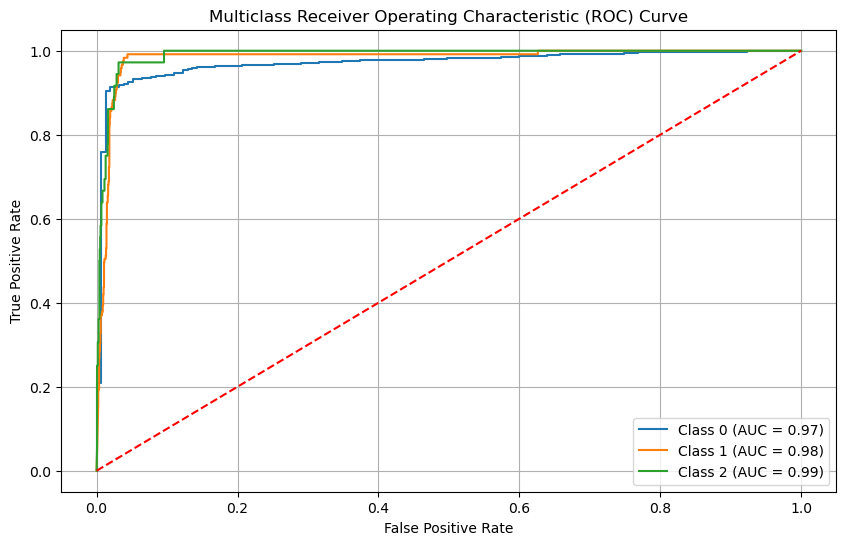

In [20]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

#Predict probabilities 
y_prob = best_model.predict_proba(X_test_imputed)

# multiclassification 
y_test_classes = label_binarize(y_test_imputed, classes=[0,1,2])

fpr ={}
tpr = {}
roc_auc = {}

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_classes[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])


plt.figure(figsize=(10, 6))
for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

## Analyzing Coefficients 

In [21]:
feature_names = X_train_imputed.columns 
coef = best_model.named_steps['model'].coef_

In [22]:
# Place feature names in a dataframe
feat_df = pd.DataFrame(coef, columns= feature_names)
feat_df.index = ['neither','hypothyroid','hyperthyroid']
feat_df

,age,sex,FTI,T3,T4U,TSH,TT4,I131 treatment,goitre,hypopituitary,...,query on thyroxine,sick,thyroid surgery,tumor,FTI_missing,T3_missing,T4U_missing,TSH_missing,TT4_missing,sex_missing
neither,-0.261764,0.279202,-1.381052,-1.622184,0.257139,-16.793257,-0.290200,0.096914,1.570804,0.038399,...,-0.060291,-0.028977,1.570723,-0.359123,0.138942,-0.468220,-0.161681,-0.010498,1.266844,0.297556
hypothyroid,0.204273,-0.260039,-0.618903,-0.813283,0.591288,21.329674,-0.911759,-0.172088,-0.787194,-0.098063,...,0.068221,-0.242872,-2.564194,0.082707,0.955959,0.394878,-0.633774,-9.426821,-0.215110,-0.343353
hyperthyroid,0.014031,-0.381643,1.244234,3.540272,-1.232641,-15.457283,1.694018,-0.052353,-0.903188,0.008715,...,-0.006329,0.293990,-1.244360,0.543016,-0.452816,1.932585,0.543145,0.167805,-3.917234,-0.114457


In [23]:
# convert to odds ratio 

odds_ratio = np.exp(coef)
odds_ratio_df = pd.DataFrame(odds_ratio, columns = feature_names)
odds_ratio_df.index = ['neither','hypothyroid','hyperthyroid']
odds_ratio_df

,age,sex,FTI,T3,T4U,TSH,TT4,I131 treatment,goitre,hypopituitary,...,query on thyroxine,sick,thyroid surgery,tumor,FTI_missing,T3_missing,T4U_missing,TSH_missing,TT4_missing,sex_missing
neither,0.769693,1.322074,0.251314,0.197467,1.293224,5.090743e-08,0.748114,1.101766,4.810515,1.039145,...,0.941490,0.971438,4.810125,0.698288,1.149057,0.626116,0.850713,0.989557,3.549632,1.346564
hypothyroid,1.226632,0.771022,0.538535,0.443400,1.806314,1.833833e+09,0.401817,0.841905,0.455120,0.906592,...,1.070602,0.784372,0.076981,1.086223,2.601163,1.484203,0.530585,0.000081,0.806453,0.709388
hyperthyroid,1.014130,0.682739,3.470274,34.476293,0.291522,1.936366e-07,5.441299,0.948994,0.405275,1.008753,...,0.993691,1.341770,0.288125,1.721190,0.635835,6.907346,1.721413,1.182706,0.019896,0.891850


In [24]:
#greatest to least odds ratio --- hypothyroid 
odds_df_sorted_hyper = odds_ratio_df.loc['hypothyroid'].sort_values(ascending=False)
odds_df_sorted_hyper

TSH                          1.833833e+09
FTI_missing                  2.601163e+00
T4U                          1.806314e+00
T3_missing                   1.484203e+00
query hyperthyroid           1.233555e+00
age                          1.226632e+00
tumor                        1.086223e+00
query on thyroxine           1.070602e+00
lithium                      9.918991e-01
query hypothyroid            9.190607e-01
hypopituitary                9.065921e-01
psych                        8.916471e-01
I131 treatment               8.419047e-01
TT4_missing                  8.064528e-01
sick                         7.843722e-01
sex                          7.710215e-01
sex_missing                  7.093875e-01
FTI                          5.385351e-01
T4U_missing                  5.305854e-01
goitre                       4.551201e-01
T3                           4.434000e-01
TT4                          4.018169e-01
on antithyroid medication    2.658293e-01
thyroid surgery              7.698

In [25]:
#greatest to least odds ratio --- hyperthyroid
odds_df_sorted_hypo = odds_ratio_df.loc['hyperthyroid'].sort_values(ascending=False)
odds_df_sorted_hypo

T3                           3.447629e+01
T3_missing                   6.907346e+00
TT4                          5.441299e+00
FTI                          3.470274e+00
query hyperthyroid           2.044933e+00
T4U_missing                  1.721413e+00
tumor                        1.721190e+00
sick                         1.341770e+00
on antithyroid medication    1.284154e+00
TSH_missing                  1.182706e+00
age                          1.014130e+00
hypopituitary                1.008753e+00
query on thyroxine           9.936906e-01
I131 treatment               9.489936e-01
sex_missing                  8.918503e-01
sex                          6.827390e-01
FTI_missing                  6.358349e-01
pregnant                     6.091476e-01
lithium                      5.669477e-01
query hypothyroid            4.952759e-01
goitre                       4.052755e-01
T4U                          2.915216e-01
thyroid surgery              2.881252e-01
on thyroxine                 2.536

In [26]:
#greatest to least odds ratio --- neither 
odds_df_sorted_neither = odds_ratio_df.loc['neither'].sort_values(ascending=False)
odds_df_sorted_neither

goitre                       4.810515e+00
thyroid surgery              4.810125e+00
on thyroxine                 3.715898e+00
TT4_missing                  3.549632e+00
psych                        1.356723e+00
sex_missing                  1.346564e+00
sex                          1.322074e+00
pregnant                     1.298525e+00
T4U                          1.293224e+00
FTI_missing                  1.149057e+00
I131 treatment               1.101766e+00
lithium                      1.057585e+00
hypopituitary                1.039145e+00
query hypothyroid            1.001259e+00
TSH_missing                  9.895571e-01
sick                         9.714385e-01
query on thyroxine           9.414904e-01
on antithyroid medication    8.994390e-01
T4U_missing                  8.507126e-01
age                          7.696925e-01
TT4                          7.481136e-01
tumor                        6.982885e-01
query hyperthyroid           6.623895e-01
T3_missing                   6.261

## Plotting Best Model Log Reg Odds Ratio 

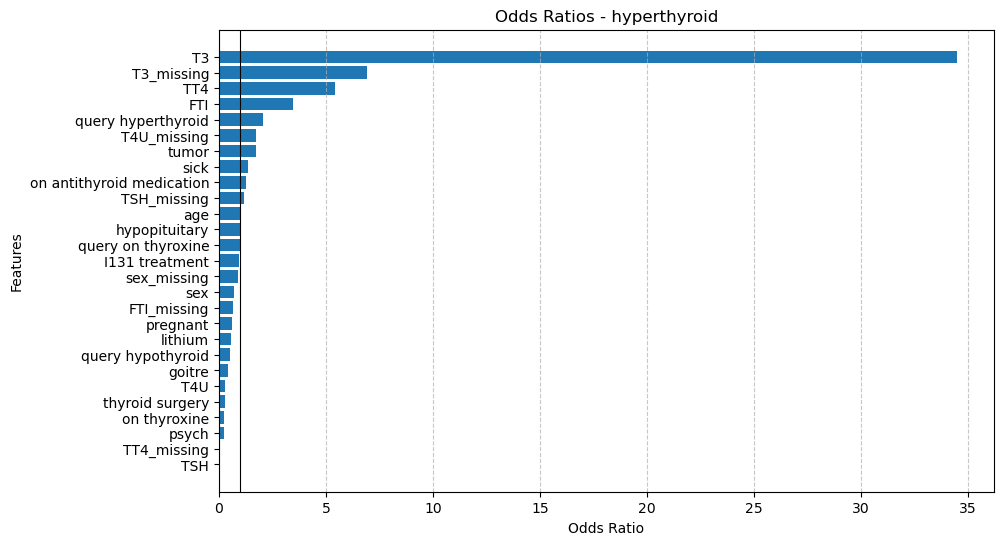

In [27]:
cls = 'hyperthyroid'
feat_odds = odds_ratio_df.loc[cls].sort_values(ascending=True)
        
plt.figure(figsize=(10, 6))
plt.barh(feat_odds.index, feat_odds.values)
plt.axvline(1, color='black', lw=0.8)  # 1 = no effect
plt.title(f'Odds Ratios - {cls}')
plt.xlabel('Odds Ratio')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


Based on the Odds Ratio graph, for every one unit increase in the T3 variable, the chances of having hyperthroidism increases slightly more than 35 times. 

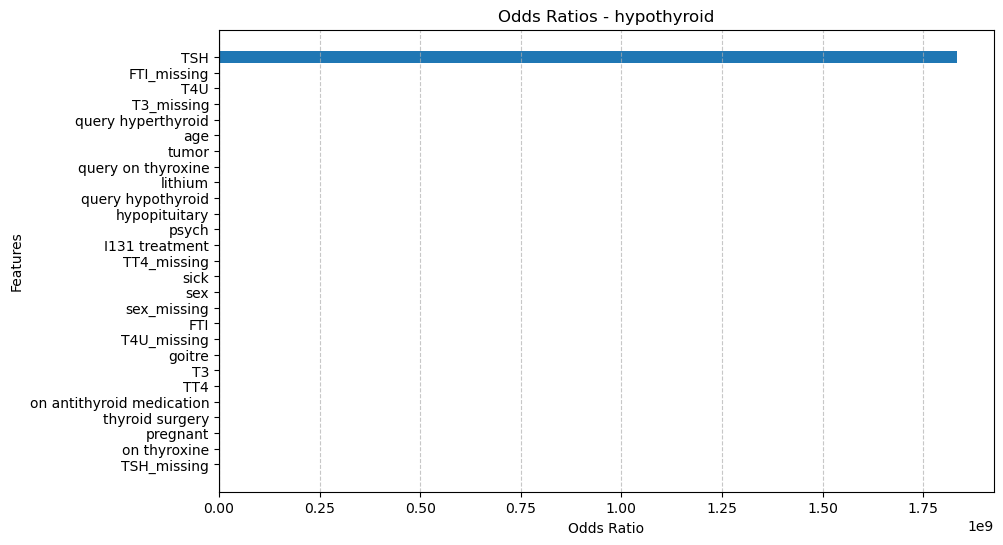

In [28]:
cls = 'hypothyroid'
feat_odds = odds_ratio_df.loc[cls].sort_values(ascending=True)
        
plt.figure(figsize=(10, 6))
plt.barh(feat_odds.index, feat_odds.values)
plt.axvline(1, color='black', lw=0.8)  # 1 = no effect
plt.title(f'Odds Ratios - {cls}')
plt.xlabel('Odds Ratio')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

For every one unit increase in the TSH variable, the chances of having hypothyroidism increases by about ~1.75 times. 

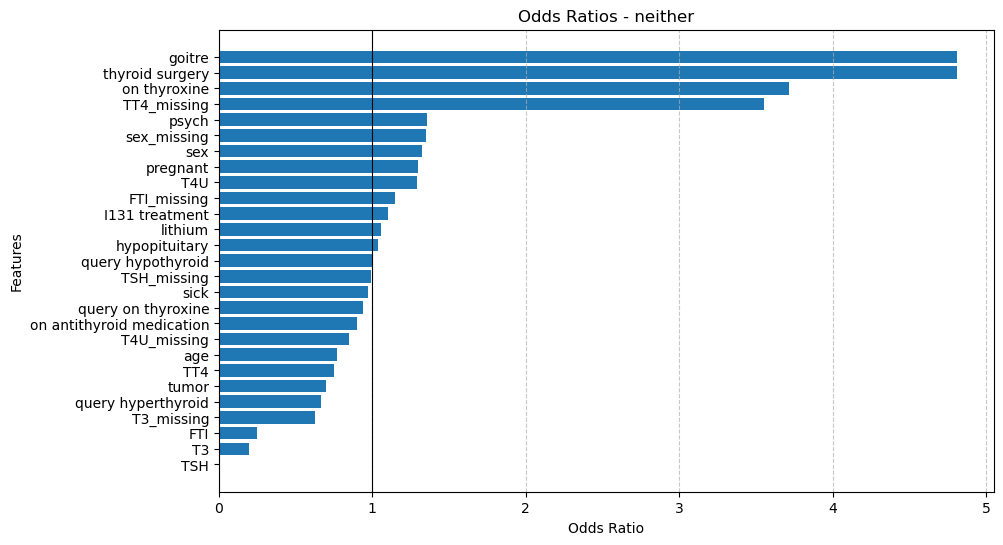

In [29]:
cls = 'neither'
feat_odds = odds_ratio_df.loc[cls].sort_values(ascending=True)
        
plt.figure(figsize=(10, 6))
plt.barh(feat_odds.index, feat_odds.values)
plt.axvline(1, color='black', lw=0.8)  # 1 = no effect
plt.title(f'Odds Ratios - {cls}')
plt.xlabel('Odds Ratio')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## Correlations

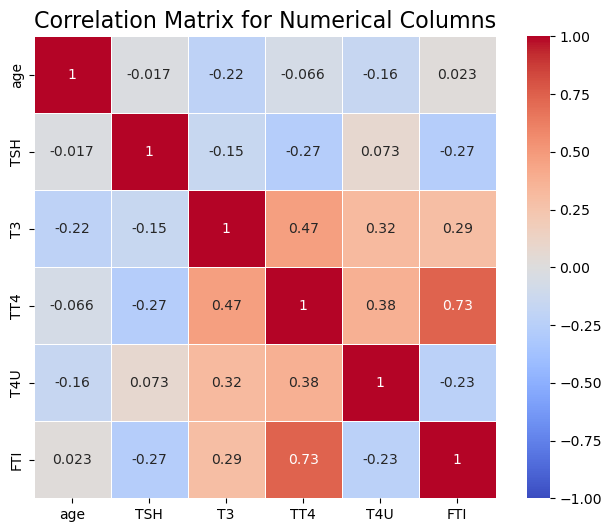

In [30]:
#numerical columns 

num_cols = ['age','TSH','T3','TT4','T4U','FTI']

correlation_matrix = train_imputed[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5, square=True)
plt.title('Correlation Matrix for Numerical Columns', fontsize=16)
plt.show()

## Model without SMOTENN: Imputation Using IterativeImputer

In [31]:
from sklearn.model_selection import GridSearchCV
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer


# Define the parameter grid, using non imputed data

pipeline_lr = Pipeline([
    ('imputer', IterativeImputer()), #use imputation instead of smotenn
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        solver='liblinear',
        random_state = 6740,
        max_iter = 1000
    ))
])

param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],  # Inverse of regularization strength
    'model__penalty': ['l1', 'l2'],  # regularization, feature selection 
}

# Instantiate the GridSearchCV
grid_search = GridSearchCV(pipeline_lr, 
                           param_grid, 
                           scoring='f1_macro', 
                           cv=5)

# Fit the model
grid_search.fit(X_train_nonimputed, y_train_nonimputed)

# Best parameters
print("Best parameters found: ", grid_search.best_params_)

# Use the best model to predict
best_model_noSMOTENN = grid_search.best_estimator_
y_pred_best = best_model_noSMOTENN.predict(X_test_nonimputed)

# Evaluate the model
print('Accuracy:', accuracy_score(y_test_nonimputed, y_pred_best))
print(classification_report(y_test_nonimputed, y_pred_best))

Best parameters found:  {'model__C': 10, 'model__penalty': 'l1'}
Accuracy: 0.9471101417666303
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1679
           1       0.85      0.48      0.61       119
           2       0.74      0.47      0.58        36

    accuracy                           0.95      1834
   macro avg       0.85      0.65      0.72      1834
weighted avg       0.94      0.95      0.94      1834



## Model without SMOTENN: Imputation Using SimpleImputer

In [32]:
from sklearn.model_selection import GridSearchCV
from sklearn.impute import SimpleImputer

# Define the parameter grid

pipeline_lr = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), #use imputation instead of smotenn
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        solver='liblinear',
        random_state = 6740,
        max_iter = 1000
    ))
])

param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],  # Inverse of regularization strength
    'model__penalty': ['l1', 'l2'],  # regularization, feature selection 
}

# Instantiate the GridSearchCV
grid_search = GridSearchCV(pipeline_lr, 
                           param_grid, 
                           scoring='f1_macro', 
                           cv=5)

# Fit the model
grid_search.fit(X_train_nonimputed, y_train_nonimputed)

# Best parameters
print("Best parameters found: ", grid_search.best_params_)

# Use the best model to predict
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_nonimputed)

# Evaluate the model
print('Accuracy:', accuracy_score(y_test_nonimputed, y_pred_best))
print(classification_report(y_test_nonimputed, y_pred_best))

Best parameters found:  {'model__C': 1, 'model__penalty': 'l2'}
Accuracy: 0.9487459105779716
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1679
           1       0.88      0.48      0.62       119
           2       0.75      0.50      0.60        36

    accuracy                           0.95      1834
   macro avg       0.86      0.66      0.73      1834
weighted avg       0.95      0.95      0.94      1834

